# Data Loading

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [2]:
import os
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

# 1. Setup Device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Using device: {device}")

# 2. Fast Data Loading
data_dir = '/content/drive/MyDrive/PolaritonicONN/TrainingDataset' # Update this if your folder name is different
spectra_data = np.load(os.path.join(data_dir, 'spectra_compiled.npy'))
geometry_data = np.load(os.path.join(data_dir, 'geometry_compiled.npy'))

# 3. Proper Scaling
# Global Normalization for Spectra
spec_min, spec_max = spectra_data.min(), spectra_data.max()
spectra_normalized = (spectra_data - spec_min) / (spec_max - spec_min)

# Standard Scaling for Geometry
scaler_geom = StandardScaler()
geometry_scaled = scaler_geom.fit_transform(geometry_data)

# 4. PyTorch DataLoaders
spectra_tensor = torch.tensor(spectra_normalized, dtype=torch.float32)
geometry_tensor = torch.tensor(geometry_scaled, dtype=torch.float32)

# When we load a batch, it will yield: (batch_spectra, batch_geometry)
dataset = TensorDataset(spectra_tensor, geometry_tensor)
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

print("Data loaded!")

Using device: cpu


FileNotFoundError: [Errno 2] No such file or directory: '/content/drive/MyDrive/PolaritonicONN/TrainingDataset/spectra_compiled.npy'

# ML Model

In [ ]:
# --- 1. FORWARD MODEL (Geometry -> Spectrum) ---
class ForwardMLP(nn.Module):
    def __init__(self):
        super(ForwardMLP, self).__init__()
        self.net = nn.Sequential(
            nn.Linear(8, 64), nn.ReLU(),
            nn.Linear(64, 128), nn.ReLU(),
            nn.Linear(128, 256), nn.ReLU(),
            nn.Linear(256, 100) # Outputs a 100-point spectrum
        )
    def forward(self, x):
        return self.net(x)

# --- 2. INVERSE MODEL (Spectrum -> Geometry) ---
class InverseCNN(nn.Module):
    def __init__(self):
        super(InverseCNN, self).__init__()
        self.conv1 = nn.Conv1d(1, 16, kernel_size=5, stride=1, padding=2)
        self.conv2 = nn.Conv1d(16, 32, kernel_size=5, stride=2, padding=2)
        self.conv3 = nn.Conv1d(32, 64, kernel_size=5, stride=2, padding=2)

        self.fc1 = nn.Linear(64 * 25, 128)
        self.fc2 = nn.Linear(128, 8) # Outputs 8 geometry parameters
        self.relu = nn.ReLU()

    def forward(self, x):
        x = x.unsqueeze(1) # Reshape 100 points into a 1-channel signal
        x = self.relu(self.conv1(x))
        x = self.relu(self.conv2(x))
        x = self.relu(self.conv3(x))
        x = x.view(x.size(0), -1)
        x = self.relu(self.fc1(x))
        return self.fc2(x)

forward_model = ForwardMLP().to(device)
inverse_model = InverseCNN().to(device)
print("Models defined and moved to device!")

Models defined and moved to device!


# Training of Froward Model

Training Forward Model (Geometry -> Spectrum)...
Epoch [10/100], Train Loss: 0.0005, Val Loss: 0.0006
Epoch [20/100], Train Loss: 0.0002, Val Loss: 0.0002
Epoch [30/100], Train Loss: 0.0001, Val Loss: 0.0002
Epoch [40/100], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [50/100], Train Loss: 0.0001, Val Loss: 0.0001
Epoch [60/100], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [70/100], Train Loss: 0.0000, Val Loss: 0.0000
Epoch [80/100], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [90/100], Train Loss: 0.0000, Val Loss: 0.0001
Epoch [100/100], Train Loss: 0.0000, Val Loss: 0.0000

Forward Model trained and frozen!


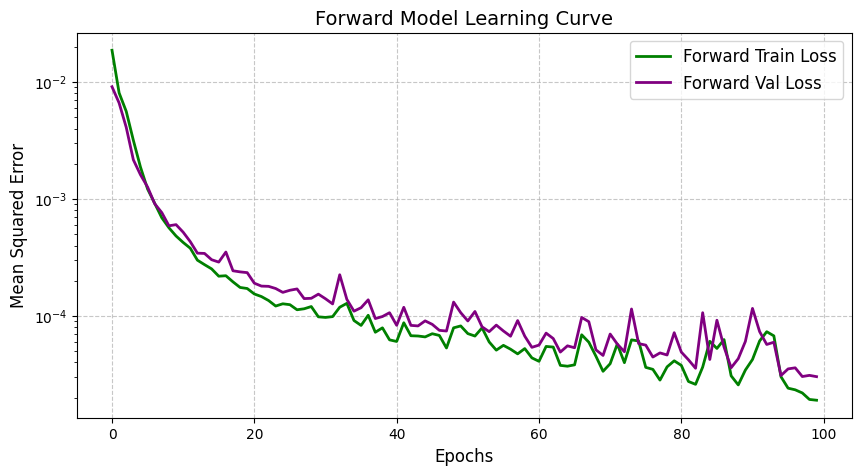

In [ ]:
import matplotlib.pyplot as plt

criterion = nn.MSELoss()
optimizer_fwd = optim.Adam(forward_model.parameters(), lr=0.001)

fwd_epochs = 100
fwd_train_losses = []
fwd_val_losses = []

print("Training Forward Model (Geometry -> Spectrum)...")
for epoch in range(fwd_epochs):
    # --- TRAINING ---
    forward_model.train()
    running_train_loss = 0.0
    for batch_spectra, batch_geometry in train_loader:
        batch_spectra, batch_geometry = batch_spectra.to(device), batch_geometry.to(device)

        pred_spectra = forward_model(batch_geometry)
        loss = criterion(pred_spectra, batch_spectra)

        optimizer_fwd.zero_grad()
        loss.backward()
        optimizer_fwd.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    fwd_train_losses.append(avg_train_loss)

    # --- VALIDATION ---
    forward_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_spectra, val_geometry in val_loader:
            val_spectra, val_geometry = val_spectra.to(device), val_geometry.to(device)
            val_pred_spectra = forward_model(val_geometry)
            val_loss = criterion(val_pred_spectra, val_spectra)
            running_val_loss += val_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    fwd_val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{fwd_epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# --- FREEZE THE MODEL ---
for param in forward_model.parameters():
    param.requires_grad = False
forward_model.eval()
print("\nForward Model trained and frozen!")

# --- PLOT THE FORWARD LOSS ---
plt.figure(figsize=(10, 5))
plt.plot(fwd_train_losses, label='Forward Train Loss', color='green', linewidth=2)
plt.plot(fwd_val_losses, label='Forward Val Loss', color='purple', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error', fontsize=12)
plt.title('Forward Model Learning Curve', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log')
plt.show()

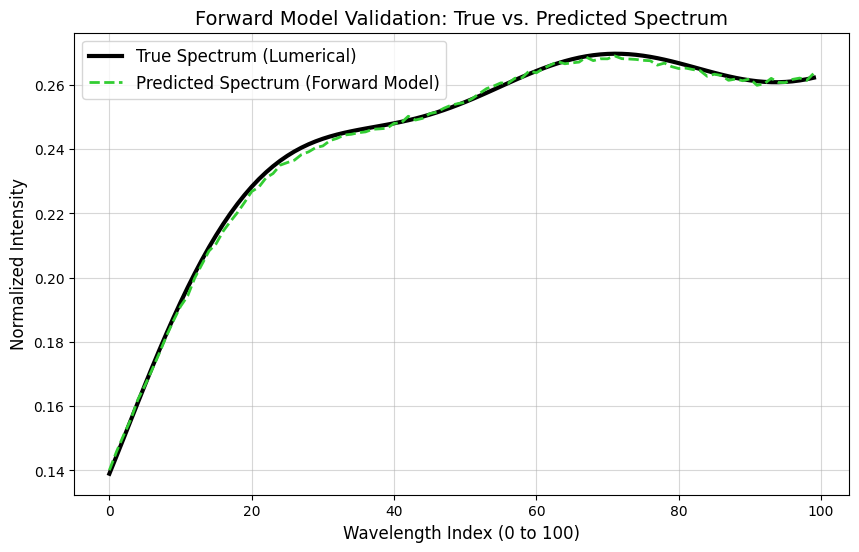

In [ ]:
# Grab one batch of validation data
batch_spectra, batch_geometry = next(iter(val_loader))

# Take the first sample
true_spectrum = batch_spectra[0].unsqueeze(0).to(device)
true_geometry = batch_geometry[0].unsqueeze(0).to(device)

# 1. Forward Model makes a prediction
with torch.no_grad():
    predicted_spectrum = forward_model(true_geometry)

# Move back to CPU for plotting
true_spectrum_np = true_spectrum.cpu().numpy().squeeze()
predicted_spectrum_np = predicted_spectrum.cpu().numpy().squeeze()

# --- PLOT THE SPECTRA ---
plt.figure(figsize=(10, 6))
plt.plot(true_spectrum_np, label='True Spectrum (Lumerical)', color='black', linewidth=3)
plt.plot(predicted_spectrum_np, label='Predicted Spectrum (Forward Model)', color='limegreen', linestyle='--', linewidth=2)
plt.xlabel('Wavelength Index (0 to 100)', fontsize=12)
plt.ylabel('Normalized Intensity', fontsize=12)
plt.title('Forward Model Validation: True vs. Predicted Spectrum', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# Training of Inverse Model

Starting Tandem Training (Solving the Inverse Problem)...
Epoch [10/100], Train Loss: 0.0133, Val Loss: 0.0130
Epoch [20/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [30/100], Train Loss: 0.0133, Val Loss: 0.0130
Epoch [40/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [50/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [60/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [70/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [80/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [90/100], Train Loss: 0.0132, Val Loss: 0.0130
Epoch [100/100], Train Loss: 0.0132, Val Loss: 0.0130


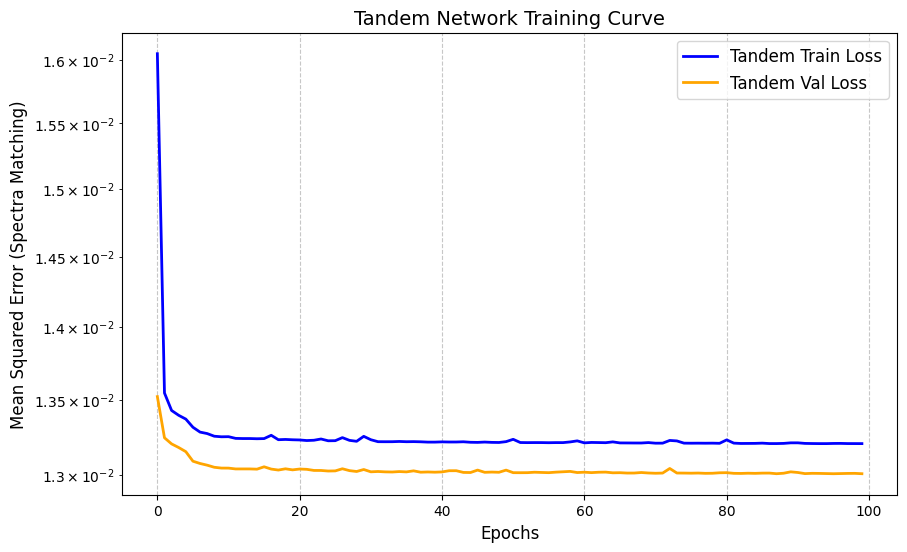

In [ ]:
import matplotlib.pyplot as plt

optimizer_inv = optim.Adam(inverse_model.parameters(), lr=0.001)
epochs = 100

tandem_train_losses = []
tandem_val_losses = []

print("Starting Tandem Training (Solving the Inverse Problem)...")
for epoch in range(epochs):
    # --- TRAINING ---
    inverse_model.train()
    running_train_loss = 0.0
    for batch_spectra, _ in train_loader:
        batch_spectra = batch_spectra.to(device)

        guessed_geometry = inverse_model(batch_spectra)
        produced_spectra = forward_model(guessed_geometry)
        loss = criterion(produced_spectra, batch_spectra)

        optimizer_inv.zero_grad()
        loss.backward()
        optimizer_inv.step()
        running_train_loss += loss.item()

    avg_train_loss = running_train_loss / len(train_loader)
    tandem_train_losses.append(avg_train_loss)

    # --- VALIDATION ---
    inverse_model.eval()
    running_val_loss = 0.0
    with torch.no_grad():
        for val_spectra, _ in val_loader:
            val_spectra = val_spectra.to(device)
            val_guessed_geometry = inverse_model(val_spectra)
            val_produced_spectra = forward_model(val_guessed_geometry)
            val_loss = criterion(val_produced_spectra, val_spectra)
            running_val_loss += val_loss.item()

    avg_val_loss = running_val_loss / len(val_loader)
    tandem_val_losses.append(avg_val_loss)

    if (epoch + 1) % 10 == 0:
        print(f"Epoch [{epoch+1}/{epochs}], Train Loss: {avg_train_loss:.4f}, Val Loss: {avg_val_loss:.4f}")

# --- PLOT THE LOSS ---
plt.figure(figsize=(10, 6))
plt.plot(tandem_train_losses, label='Tandem Train Loss', color='blue', linewidth=2)
plt.plot(tandem_val_losses, label='Tandem Val Loss', color='orange', linewidth=2)
plt.xlabel('Epochs', fontsize=12)
plt.ylabel('Mean Squared Error (Spectra Matching)', fontsize=12)
plt.title('Tandem Network Training Curve', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, linestyle='--', alpha=0.7)
plt.yscale('log')
plt.show()

PHYSICAL GEOMETRY COMPARISON
-----------------------------------------------------------------
Parameter          | Ground Truth         | Model Prediction    
-----------------------------------------------------------------
Layer 1 Radius (m) |           6.2500e-07 |           1.1897e-06
Layer 1 Theta (rad)|               0.7854 |               0.5776
Layer 2 Radius (m) |           1.0000e-06 |           4.3517e-07
Layer 2 Theta (rad)|               1.5708 |               2.2779
Layer 3 Radius (m) |           6.2500e-07 |           5.8658e-07
Layer 3 Theta (rad)|               3.9270 |               4.0499
Layer 4 Radius (m) |           6.2500e-07 |           5.8533e-07
Layer 4 Theta (rad)|               4.7124 |               5.6302
-----------------------------------------------------------------

*Note: If parameters differ but spectra match perfectly, you have successfully witnessed physics degeneracy!*



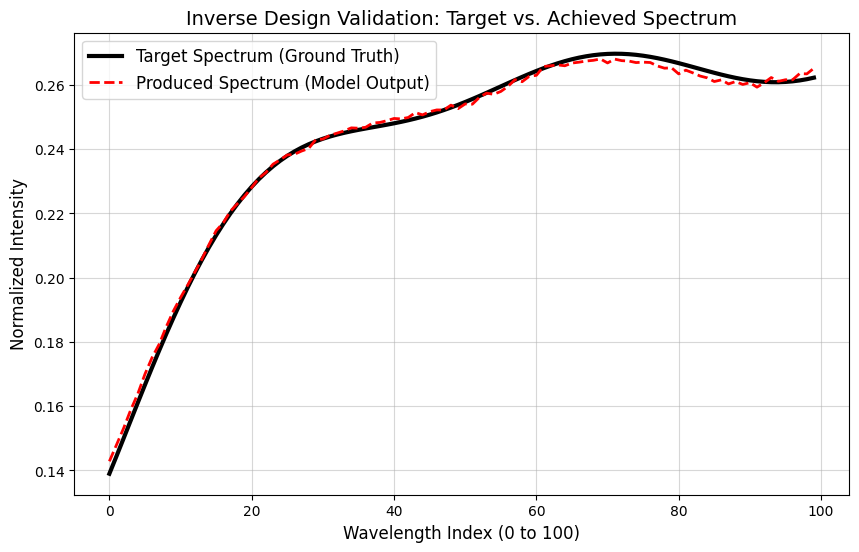

In [ ]:
# Grab one batch of validation data
inverse_model.eval()
forward_model.eval()
batch_spectra, batch_geometry = next(iter(val_loader))

# Take the first sample from the batch
target_spectrum = batch_spectra[0].unsqueeze(0).to(device)
true_geometry_scaled = batch_geometry[0].unsqueeze(0).numpy()

# 1. Model makes a prediction
with torch.no_grad():
    predicted_geometry_scaled = inverse_model(target_spectrum)
    produced_spectrum = forward_model(predicted_geometry_scaled)

# Move back to CPU for plotting/printing
target_spectrum_np = target_spectrum.cpu().numpy().squeeze()
produced_spectrum_np = produced_spectrum.cpu().numpy().squeeze()

# 2. Un-scale the geometry to real physical units
true_geom_physical = scaler_geom.inverse_transform(true_geometry_scaled)[0]
pred_geom_physical = scaler_geom.inverse_transform(predicted_geometry_scaled.cpu().numpy())[0]

# --- PRINT PHYSICAL PARAMETERS ---
print("PHYSICAL GEOMETRY COMPARISON")
print("-" * 65)
print(f"{'Parameter':<18} | {'Ground Truth':<20} | {'Model Prediction':<20}")
print("-" * 65)
for i in range(4):
    print(f"Layer {i+1} Radius (m) | {true_geom_physical[i*2]:>20.4e} | {pred_geom_physical[i*2]:>20.4e}")
    print(f"Layer {i+1} Theta (rad)| {true_geom_physical[i*2 + 1]:>20.4f} | {pred_geom_physical[i*2 + 1]:>20.4f}")
print("-" * 65)
print("\n*Note: If parameters differ but spectra match perfectly, you have successfully witnessed physics degeneracy!*\n")

# --- PLOT THE SPECTRA ---
plt.figure(figsize=(10, 6))
# We can un-normalize the spectra for the plot if we want, but plotting the 0-1 scale is fine for visual check
plt.plot(target_spectrum_np, label='Target Spectrum (Ground Truth)', color='black', linewidth=3)
plt.plot(produced_spectrum_np, label='Produced Spectrum (Model Output)', color='red', linestyle='--', linewidth=2)
plt.xlabel('Wavelength Index (0 to 100)', fontsize=12)
plt.ylabel('Normalized Intensity', fontsize=12)
plt.title('Inverse Design Validation: Target vs. Achieved Spectrum', fontsize=14)
plt.legend(fontsize=12)
plt.grid(True, alpha=0.5)
plt.show()

# Saving the Model

In [ ]:
import joblib
import os

# 1. Save the trained Inverse Model
inverse_save_path = os.path.join(data_dir, 'inverse_model_tandem.pth')
torch.save(inverse_model.state_dict(), inverse_save_path)

# 2. Save the Geometry Scaler
scaler_save_path = os.path.join(data_dir, 'scaler_geom.pkl')
joblib.dump(scaler_geom, scaler_save_path)

# 3. Save the Spectra Min/Max values
limits_save_path = os.path.join(data_dir, 'spec_min_max.npy')
np.save(limits_save_path, np.array([spec_min, spec_max]))

print("Success! Inverse Model, Scaler, and Min/Max limits safely backed up.")

Success! Inverse Model, Scaler, and Min/Max limits safely backed up.


# Export Current Predictions for Simulation

In [ ]:
export_path = os.path.join(data_dir, 'lumerical_test_parameters.csv')

# Save as a simple comma-separated file
np.savetxt(export_path, pred_geom_physical, delimiter=",",
           header="Radius1,Theta1,Radius2,Theta2,Radius3,Theta3,Radius4,Theta4",
           comments='')

print(f"Parameters exported for Lumerical: {export_path}")

Parameters exported for Lumerical: /content/drive/MyDrive/PolaritonicONN/TrainingDataset/lumerical_test_parameters.csv
